In [2]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

### Test set iamge Processing

In [4]:
validation_set = tf.keras.utils.image_dataset_from_directory(
    "../data/ PlantDisease/Dataset/valid",
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(128, 128),
    shuffle=True,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False,
    pad_to_aspect_ratio=False,
    data_format=None,
    format="tf",
    verbose=True,
)


Found 17572 files belonging to 38 classes.


In [5]:
class_name = validation_set.class_names
class_name

['Apple___Apple_scab',
 'Apple___Black_rot',
 'Apple___Cedar_apple_rust',
 'Apple___healthy',
 'Blueberry___healthy',
 'Cherry_(including_sour)___Powdery_mildew',
 'Cherry_(including_sour)___healthy',
 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot',
 'Corn_(maize)___Common_rust_',
 'Corn_(maize)___Northern_Leaf_Blight',
 'Corn_(maize)___healthy',
 'Grape___Black_rot',
 'Grape___Esca_(Black_Measles)',
 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)',
 'Grape___healthy',
 'Orange___Haunglongbing_(Citrus_greening)',
 'Peach___Bacterial_spot',
 'Peach___healthy',
 'Pepper,_bell___Bacterial_spot',
 'Pepper,_bell___healthy',
 'Potato___Early_blight',
 'Potato___Late_blight',
 'Potato___healthy',
 'Raspberry___healthy',
 'Soybean___healthy',
 'Squash___Powdery_mildew',
 'Strawberry___Leaf_scorch',
 'Strawberry___healthy',
 'Tomato___Bacterial_spot',
 'Tomato___Early_blight',
 'Tomato___Late_blight',
 'Tomato___Leaf_Mold',
 'Tomato___Septoria_leaf_spot',
 'Tomato___Spider_mites Two-spotted_

### Loading Model

In [7]:
model = tf.keras.models.load_model("trained_plant_disease_model.keras")

### Visualising and Performing Prediction on Single image

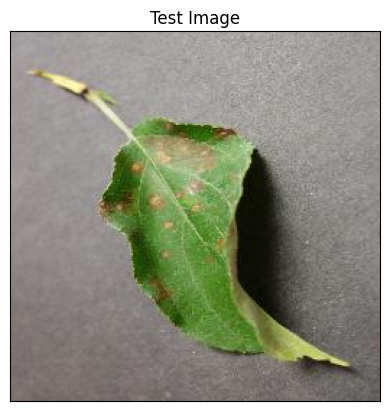

In [8]:
import cv2
image_path = '../data/ PlantDisease/Dataset/test/AppleCedarRust3.JPG'
img = cv2.imread(image_path)
img  = cv2.cvtColor(img,cv2.COLOR_BGR2RGB) #convert BGR to RGB
#display Image
plt.imshow(img)
plt.xticks([])
plt.yticks([])
plt.title('Test Image')

plt.show()

### Testing Model

In [10]:
image  =tf.keras.preprocessing.image.load_img(image_path ,target_size=(128 ,128))
input_arr = tf.keras.preprocessing.image.img_to_array(image)
input_arr = np.array([input_arr]) # convert a single iamge to batch (bcoz teh network works with (batch size,128 ,128 ,3))
prediction  = model.predict(input_arr)
prediction

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step


array([[1.3509009e-06, 1.9189922e-06, 9.9945194e-01, 9.2260954e-05,
        2.3037327e-08, 1.4512574e-05, 2.6201635e-08, 3.0919226e-05,
        8.9315495e-07, 6.8087627e-07, 9.2369790e-10, 9.3365048e-07,
        3.0182732e-06, 8.7043128e-09, 8.7308757e-07, 9.0183562e-07,
        1.5751485e-04, 9.7703241e-07, 2.9470769e-07, 3.5674105e-08,
        6.0586544e-08, 3.7146670e-08, 1.8238917e-07, 8.3407663e-09,
        6.6117587e-09, 8.3610274e-07, 3.1084884e-09, 3.0031644e-10,
        1.9524715e-04, 9.2518367e-06, 2.1171263e-05, 2.0938620e-07,
        4.5486786e-07, 6.9088493e-08, 1.5387041e-06, 8.5747004e-08,
        2.6941175e-08, 1.1673131e-05]], dtype=float32)

In [11]:
result_index =np.argmax(prediction)
print(result_index)

2


### Prediction

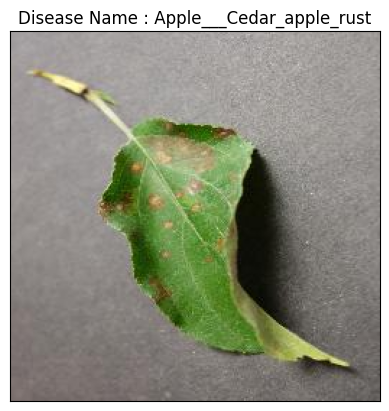

In [12]:
model_prediction = class_name[result_index]
plt.imshow(img)
plt.title(f"Disease Name : {model_prediction}")
plt.xticks([])
plt.yticks([])
plt.show()